### Read in data from Victor's analysis method

Reads in and analyzes data from bias/balzer varied runs.  Reads in from npz files.

In [45]:
#%matplotlib notebook
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import pytz
import glob

plt.rcParams['figure.dpi']=150
plt.rcParams['font.family'] = 'Serif'

def savepng(pngname): 
    plt.savefig(pngname+".png", bbox_inches="tight", facecolor='w')
symbols = ['o','*','s','^','p','X','v','D','h','<','8','>']  # these are all solids

In [46]:
def load_names(filename) :
    with open(filename) as datafile :
        names = []
        nl = 0
        while datafile.readline() : nl = nl + 1
        datafile.seek(0)
        for i in range(nl):
            names.append(datafile.readline()[3 :])
    return names[1 :]

In [47]:
names = load_names('../data/raw_text/column_names')  # load the names of the different columns
# labels can be used as axes labels when plotting
labels = ['M/Q', 'fcv in', r'O$^{7+}$ [$\mu$A]', 'balzer 1', 'balzer 2', 'balzer 5', 'balzer 6', 'balzer 7',
        'gas 1', 'gas 2','gas 5','gas 6','gas 7',r'I$_\mathrm{inj}$ [A]',r'I$_\mathrm{ext}$ [A]',
        r'I$_\mathrm{mid}$ [A]',r'I$_\mathrm{ext}$ [A]',r'V$_\mathrm{inj}$ [V]',r'V$_\mathrm{ext}$ [V]',
        r'V$_\mathrm{mid}$ [V]',r'V$_\mathrm{ext}$ [V]',r'Vps$_\mathrm{inj}$ [V]',r'Vps$_\mathrm{ext}$ [V]',
        r'Vps$_\mathrm{mid}$ [V]',r'Vps$_\mathrm{sext}$ [V]',r'injection pressure [$\cdot 10^{-7}$ torr]',
        r'extraction pressure [$\cdot 10^{-9}$ torr]',r'V$_\mathrm{bias}$ [V]',r'I$_\mathrm{bias}$ [mA]',
        '18 GHz power [kW]','reflected 18 GHz power [W]','28 GHz power [kW]',r'I$_\mathrm{glaser}$ [A]',
        r'I$_\mathrm{batman}$ [A]',r'B$_\mathrm{batman}$ [gauss]','x-ray source','x-ray exit',
        r'V$_\mathrm{extraction}$ [kV]',r'I$_\mathrm{drain}$ [mA]',r'V$_\mathrm{[puller]}$ [V]',r'I$_\mathrm{[puller]}$ [mA]',
        'puller raw gap',r'beam line pressure [$\cdot 10^{-9}$ torr]',r'I$_\mathrm{robin}$ [A]']
# some parameters are multipled by a constant to not have to deal with exponents
mult=[1,1,1e6,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1e7,1e9,1,1,1e3,1,1e3,1,1,1,1,1,1,1,1,1,1e9,1]
# 0:M/Q 1:fcvIn 2:fcv 3-7:balzers 8-12:balz_labels 13-16:Icoils 17-20:Vcoils 21-24:Vcoil_ps, 25:Pinj 
# 26:Pext 27:Vbias 28:Ibias 29:P18 30:P18ref 31:P28 32:Iglaser 33:Ibatman 34:Bbatman 35:xraySrc 36:xrayExit
# 37:Vext 38:Idrain 39:Vpull 40:Ipull 41:pullGap 42:Blin_Pressure 43:Irobin

In [48]:
filenums = glob.glob('../data/accumulated_npz/wd*')
filenums.sort()

for i in range(len(filenums)):
    last_file = filenums[i].split('/')[-1]
    last_file = last_file.split('_')[1]
    print(last_file)
    filenums[i] = last_file[:-4]
print(filenums)

00.npz
01.npz
02.npz
03.npz
04.npz
05.npz
06.npz
07.npz
08.npz
08a.npz
08b.npz
08c.npz
08d.npz
09.npz
10.npz
10b.npz
11.npz
11b.npz
12.npz
13.npz
14.npz
['00', '01', '02', '03', '04', '05', '06', '07', '08', '08a', '08b', '08c', '08d', '09', '10', '10b', '11', '11b', '12', '13', '14']


In [69]:
mean00 = {}; mean01 = {}; mean10 = {}; mean11 = {}
std00 = {}; std01 = {}; std10 = {}; std11 = {}
tt00 = {}; tt01 = {}; tt10 = {}; tt11 = {}

for fn in filenums:
    npz_kw = np.load('../data/accumulated_npz/wd_'+fn+'.npz')
    std00[fn] = npz_kw['s00']; std01[fn]=npz_kw['s01']; std10[fn]=npz_kw['s10']; std11[fn]=npz_kw['s11'];
    mean00[fn] = npz_kw['m00']; mean01[fn]=npz_kw['m01']; mean10[fn]=npz_kw['m10']; mean11[fn]=npz_kw['m11'];
    tt00[fn] = npz_kw['t00']; tt01[fn]=npz_kw['t01']; tt10[fn]=npz_kw['t10']; tt11[fn]=npz_kw['t11'];

for key in mean00.keys():
    print(len(mean00[key]), end=" ")
    print(len(mean01[key]), end=" ")
    print(len(mean10[key]), end=" ")
    print(len(mean11[key]), end=" ")
    print(" ")
    

43 798 306 2549  
5 75 34 705  
9 59 142 1407  
4 51 36 319  
0 4 1 15  
3 51 43 428  
4 120 23 1092  
0 0 0 315  
2997 3861 904 3126  
0 2 79 1651  
0 3 81 1743  
0 46 87 2723  
0 114 117 4242  
0 20 7 624  
0 6 12 339  
1 73 86 953  
0 73 28 571  
0 119 62 1856  
0 4 105 1618  
0 5 51 1183  
9 111 275 2146  


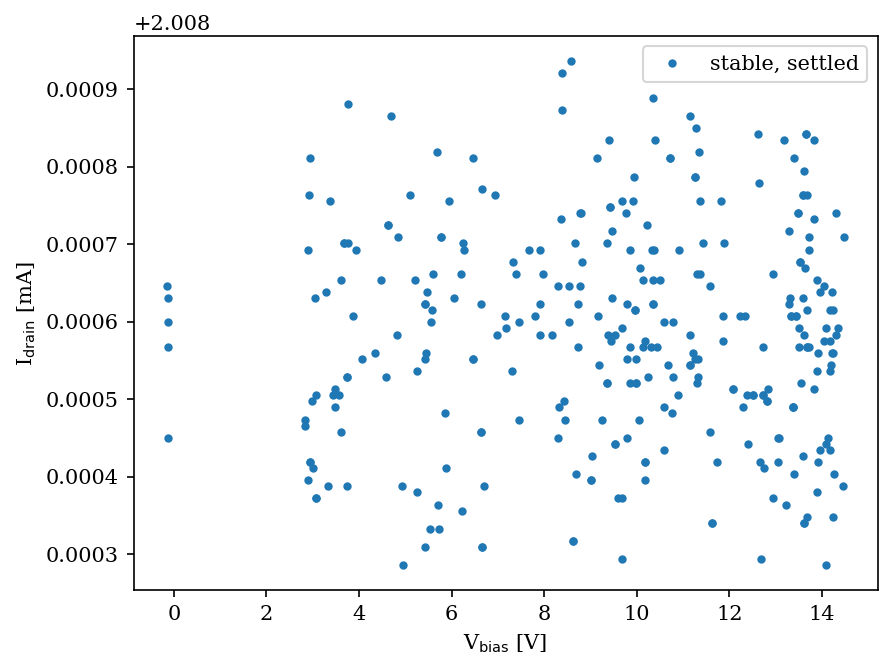

In [63]:
# 0:M/Q 1:fcvIn 2:fcv 3-7:balzers 8-12:balz_labels 13-16:Icoils 17-20:Vcoils 21-24:Vcoil_ps, 25:Pinj 
# 26:Pext 27:Vbias 28:Ibias 29:P18 30:P18ref 31:P28 32:Iglaser 33:Ibatman 34:Bbatman 35:xraySrc 36:xrayExit
# 37:Vext 38:Idrain 39:Vpull 40:Ipull 41:pullGap 42:Blin_Pressure 43:Irobin

#   0  1  2  3  4  5  6  7  8  9   10  11  12 13 14  15 16  17 18 19 20
# [00,01,02,03,04,05,06,07,08,08a,08b,08c,08d,09,10,10b,11,11b,12,13,14]
xind = 27
yind = 38
numset = 7
numsetstr = str(numset)
while(len(numsetstr)<2): numsetstr='0'+numsetstr

if 1: plt.plot(mean11[filenums[numset]][:,xind]*mult[xind],mean11[filenums[numset]][:,yind]*mult[yind],
               '.',label='stable, settled')
if 1: 
    if len(mean10[filenums[numset]])>0:
        plt.plot(mean10[filenums[numset]][:,xind]*mult[xind],mean10[filenums[numset]][:,yind]*mult[yind]
               ,'.',label='stable, not settled')
if 1: 
    if len(mean01[filenums[numset]])>0:
        plt.plot(mean01[filenums[numset]][:,xind]*mult[xind],mean01[filenums[numset]][:,yind]*mult[yind]
               ,'.',label='unstable, settled')
if 1: 
    if len(mean00[filenums[numset]])>0:
        plt.plot(mean00[filenums[numset]][:,xind]*mult[xind],mean00[filenums[numset]][:,yind]*mult[yind]
               ,'.',label='unstable, not settled')
plt.xlabel(labels[xind])
plt.ylabel(labels[yind])
plt.legend()
#savepng('images/set'+numsetstr+'_types')

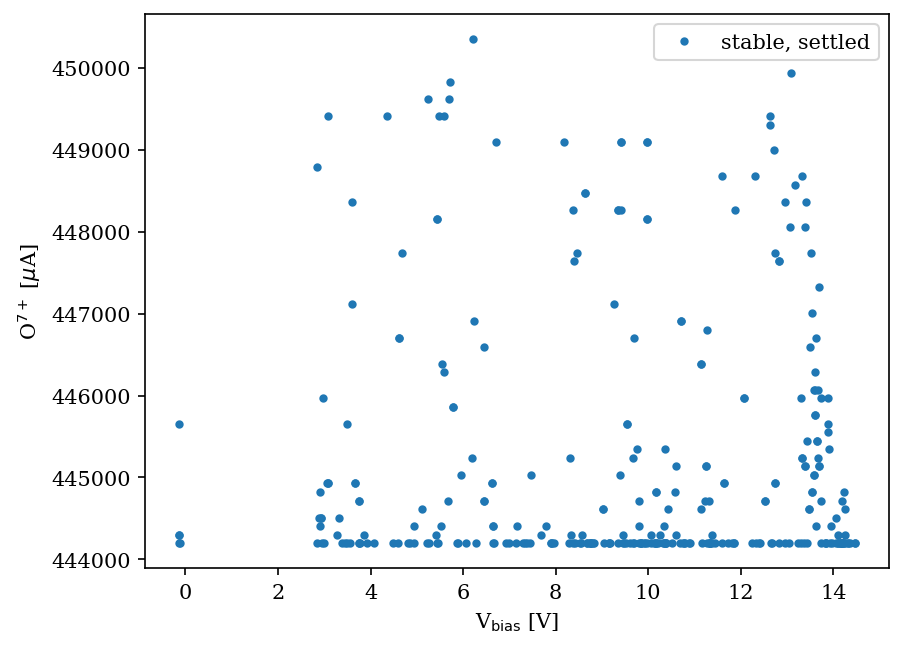

In [51]:
# 0:M/Q 1:fcvIn 2:fcv 3-7:balzers 8-12:balz_labels 13-16:Icoils 17-20:Vcoils 21-24:Vcoil_ps, 25:Pinj 
# 26:Pext 27:Vbias 28:Ibias 29:P18 30:P18ref 31:P28 32:Iglaser 33:Ibatman 34:Bbatman 35:xraySrc 36:xrayExit
# 37:Vext 38:Idrain 39:Vpull 40:Ipull 41:pullGap 42:Blin_Pressure 43:Irobin

#   0  1  2  3  4  5  6  7  8  9   10  11  12 13 14  15 16  17 18 19 20
# [00,01,02,03,04,05,06,07,08,08a,08b,08c,08d,09,10,10b,11,11b,12,13,14]
xind = 27
yind = 2

if 1: plt.plot(mean11[filenums[numset]][:,xind]*mult[xind],mean11[filenums[numset]][:,yind]*mult[yind],
               '.',label='stable, settled')
if 1: 
    if len(mean10[filenums[numset]])>0:
        plt.plot(mean10[filenums[numset]][:,xind]*mult[xind],mean10[filenums[numset]][:,yind]*mult[yind]
               ,'.',label='stable, not settled')
if 1: 
    if len(mean01[filenums[numset]])>0:
        plt.plot(mean01[filenums[numset]][:,xind]*mult[xind],mean01[filenums[numset]][:,yind]*mult[yind]
               ,'.',label='unstable, settled')
if 1: 
    if len(mean00[filenums[numset]])>0:
        plt.plot(mean00[filenums[numset]][:,xind]*mult[xind],mean00[filenums[numset]][:,yind]*mult[yind]
               ,'.',label='unstable, not settled')
plt.xlabel(labels[xind])
plt.ylabel(labels[yind])
plt.legend()
#savepng('images/set'+numsetstr+'_types_Vbias_Ibeam')

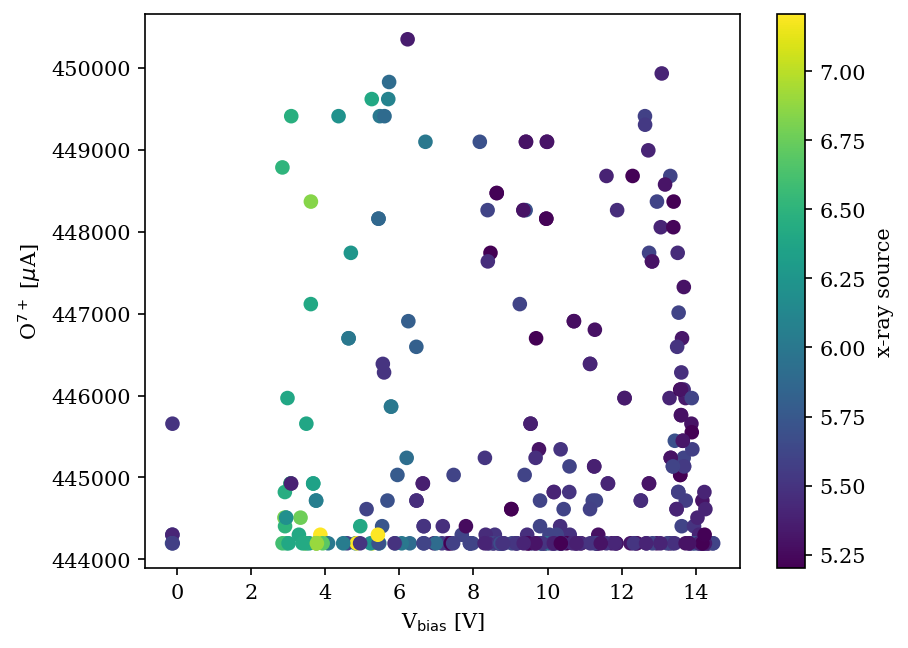

In [52]:
# 0:M/Q 1:fcvIn 2:fcv 3-7:balzers 8-12:balz_labels 13-16:Icoils 17-20:Vcoils 21-24:Vcoil_ps, 25:Pinj 
# 26:Pext 27:Vbias 28:Ibias 29:P18 30:P18ref 31:P28 32:Iglaser 33:Ibatman 34:Bbatman 35:xraySrc 36:xrayExit
# 37:Vext 38:Idrain 39:Vpull 40:Ipull 41:pullGap 42:Blin_Pressure 43:Irobin

#   0  1  2  3  4  5  6  7  8  9   10  11  12 13 14  15 16  17 18 19 20
# [00,01,02,03,04,05,06,07,08,08a,08b,08c,08d,09,10,10b,11,11b,12,13,14]
xind = 27
yind = 2
zind = 35
#numset = 17

plt.scatter(mean11[filenums[numset]][:,xind]*mult[xind],mean11[filenums[numset]][:,yind]*mult[yind],
                c=mean11[filenums[numset]][:,zind]*mult[zind])

plt.xlabel(labels[xind])
plt.ylabel(labels[yind])
cbar = plt.colorbar()
cbar.set_label(labels[zind])
#savepng('images/set'+numsetstr+'_colorbar')

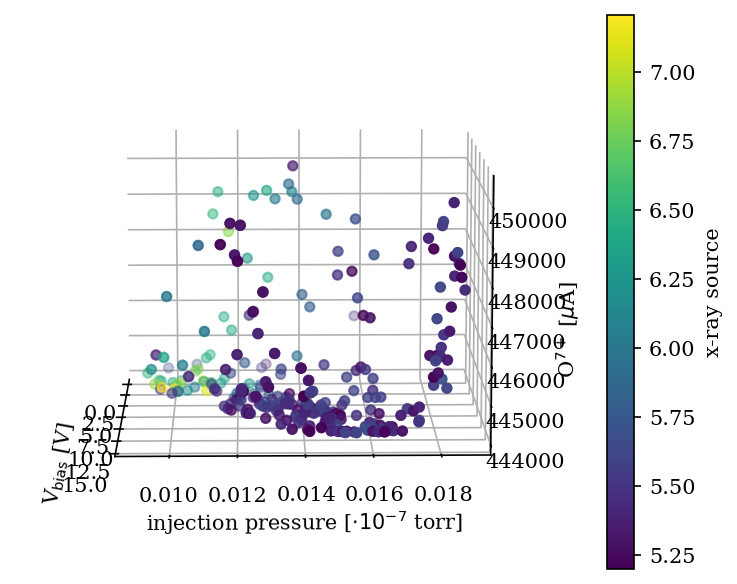

In [53]:
# 0:M/Q 1:fcvIn 2:fcv 3-7:balzers 8-12:balz_labels 13-16:Icoils 17-20:Vcoils 21-24:Vcoil_ps, 25:Pinj 
# 26:Pext 27:Vbias 28:Ibias 29:P18 30:P18ref 31:P28 32:Iglaser 33:Ibatman 34:Bbatman 35:xraySrc 36:xrayExit
# 37:Vext 38:Idrain 39:Vpull 40:Ipull 41:pullGap 42:Blin_Pressure 43:Irobin

#   0  1  2  3  4  5  6  7  8  9   10  11  12 13 14  15 16  17 18 19 20
# [00,01,02,03,04,05,06,07,08,08a,08b,08c,08d,09,10,10b,11,11b,12,13,14]
xind = 27
yind = 25
zind = 2
cind = 35
#numset = 17

fig = plt.figure()
ax = fig.add_subplot(projection = '3d')

p = ax.scatter(mean11[filenums[numset]][:,xind]*mult[xind],mean11[filenums[numset]][:,yind]*mult[yind],
           mean11[filenums[numset]][:,zind]*mult[zind],c=mean11[filenums[numset]][:,cind]*mult[cind])

ax.set_xlabel(labels[xind])
ax.set_ylabel(labels[yind])
ax.set_zlabel(labels[zind])
cbar = fig.colorbar(p)
cbar.set_label(labels[cind])

ax.xaxis.set_pane_color((1.0,1.0,1.0,1.0))
ax.yaxis.set_pane_color((1.0,1.0,1.0,1.0))
ax.zaxis.set_pane_color((1.0,1.0,1.0,1.0))
inumset = str(numset)
while len(inumset)<2: inumset = '0'+inumset
for i in range(360):
    ax.view_init(elev=10,azim=i)
    namenum = str(i)
    while len(namenum)<3: namenum = '0'+namenum
    # savepng('rot_'+inumset+'_'+namenum)

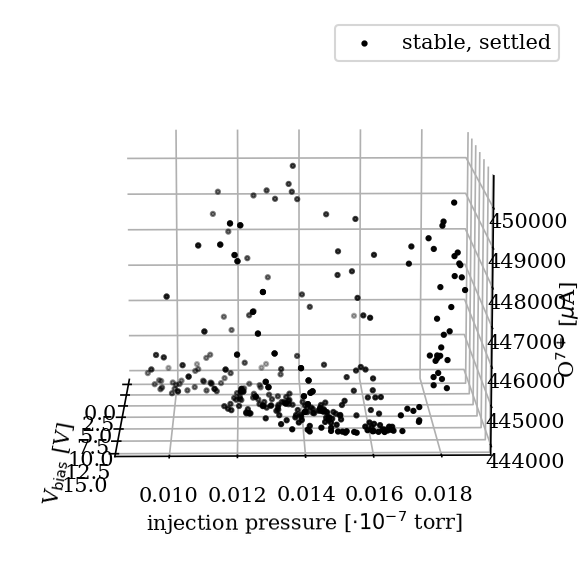

In [54]:
fig = plt.figure()
ax = fig.add_subplot(projection = '3d')

ax.scatter(mean11[filenums[numset]][:,xind]*mult[xind],mean11[filenums[numset]][:,yind]*mult[yind],
           mean11[filenums[numset]][:,zind]*mult[zind],c='k',s=4,label='stable, settled')
if len(mean10[filenums[numset]])>0:
    ax.scatter(mean10[filenums[numset]][:,xind]*mult[xind],mean10[filenums[numset]][:,yind]*mult[yind],
           mean10[filenums[numset]][:,zind]*mult[zind],c='g',s=4,label='stable, non-settled')
if len(mean01[filenums[numset]])>0:
    ax.scatter(mean01[filenums[numset]][:,xind]*mult[xind],mean01[filenums[numset]][:,yind]*mult[yind],
           mean01[filenums[numset]][:,zind]*mult[zind],c='r',s=4,label='unstable, settled')
if len(mean00[filenums[numset]])>0:
    ax.scatter(mean00[filenums[numset]][:,xind]*mult[xind],mean00[filenums[numset]][:,yind]*mult[yind],
           mean00[filenums[numset]][:,zind]*mult[zind],c='b',s=4,label='unstable, non-settled')

ax.set_xlabel(labels[xind])
ax.set_ylabel(labels[yind])
ax.set_zlabel(labels[zind])

ax.xaxis.set_pane_color((1.0,1.0,1.0,1.0))
ax.yaxis.set_pane_color((1.0,1.0,1.0,1.0))
ax.zaxis.set_pane_color((1.0,1.0,1.0,1.0))
plt.legend()
inumset = str(numset)
while len(inumset)<2: inumset = '0'+inumset
for i in range(360):
    ax.view_init(elev=10,azim=i)
    namenum = str(i)
    while len(namenum)<3: namenum = '0'+namenum
    # savepng('rot4_'+inumset+'_'+namenum)

In [55]:
for fnum in filenums:
    sets,runtime,data = load_tracking('watch_data'+fnum)  # load the run info data
    if fnum == '_00':
        runtime = load_timeinfo('../Data/timeinfo')
    nsets = int(np.shape(data)[0]/obslen)
    mean00 = []
    mean01 = []
    mean10 = []
    mean11 = []
    std00 = []
    std01 = []
    std10 = []
    std11 = []
    t00 = []
    t01 = []
    t10 = []
    t11 = []
    
    for i in range(nsets):
        mean,std,tinfo,stable,keep = check_data_ok(i,data,runtime)
        if stable==0:
            if keep==0:
                std00.append(std)
                mean00.append(mean)
                t00.append(tinfo)
            else:
                std01.append(std)
                mean01.append(mean)
                t01.append(tinfo)
        else:
            if keep==0:
                std10.append(std)
                mean10.append(mean)
                t10.append(tinfo)
            else:
                std11.append(std)
                mean11.append(mean)
                t11.append(tinfo)
    # np.savez('../Data/wd'+fnum,std00=std00,mean00=mean00,t00=t00,std01=std01,mean01=mean01,
    #          t01=t01,std10=std10,mean10=mean10,t10=t10,std11=std11,mean11=mean11,t11=t11)

FileNotFoundError: [Errno 2] No such file or directory: 'watch_data00'

In [ ]:
print(np.shape(data)[0])

In [ ]:
check_data_ok(11,data)

In [ ]:
# Make multiply y-axes

m = 49.944791*931.5   # Titanium-50 mass in MeV/c^2

# This data was retrieved from Filemaker in the control room because of laziness
KE = 5*np.arange(13)+290.0     # kinetic energies in MeV for 50Ti11+
KEu = KE/50.0                  # kinetic energy per amu
Icoil = np.array([1971,2018,2068,2118,2170,2224,2279,2336,2394,2455,2516,2580,2644])  # predicted main magnet current
f = np.array([5.40,5.45,5.49,5.54,5.58,5.63,5.67,5.72,5.76,5.80,5.85,5.89,5.93])      # predicted frequency

gamma = 1.+KE/m            # relativistic gamma
gammalow = 1.+5.74*50.0/m  # relativistic gamma lower limit for 120 search
gammahigh = 1.+6.1*50./m   # relativistic gamma upper limit for 120 search
rlow = 1.-gammalow/gamma   # how much the min of the energy range requires reducing the extraction radius [m]
rhigh = 1.-gammahigh/gamma  # how much the max of the energy range requires reducin

fig, host = plt.subplots()
ax2 = host.twinx()
ax3 = host.twinx()

p1 = host.plot(KEu,rlow*1000.0,'k--v',label=r'dr$_\mathrm{deflector}$: KE = 5.74 MeV/u')
p2 = host.plot(KEu,rhigh*1000.0,'k--^',label=r'dr$_\mathrm{deflector}$: KE = 6.1 MeV/u')
p3 = ax2.plot(KEu,f,'r-o',label=r'frequency [MHz]')
p4 = ax3.plot(KEu,Icoil,'b:x',label = r'I$_\mathrm{main}$ [A]')

ax3.spines['right'].set_position(('outward', 60))

host.set_xlabel("Beam energy at normal extraction [MeV/u]")
host.set_ylabel("Inward deflector motion for desired energy [mm]")
ax2.set_ylabel("Cyclotron frequency [MHz]")
ax3.set_ylabel("Main magnet current [A]")


ax2.yaxis.label.set_color('r')
ax3.yaxis.label.set_color('b')
plt.rcParams['hatch.color'] = 'b'
ax3.plot([5.8,7.0],[2400,2400],ls='--',c='b')
ax3.fill_between([5.8,7.0],[2400,2400],2600,hatch='X', linewidth=0.0, alpha=0.0)

plt.rcParams['hatch.color'] = 'r'
ax2.plot([5.8,7.0],[5.5993,5.5993],ls='--',c='r')
ax2.fill_between([5.8,7.0],[5.5993,5.5993],5.42,hatch='X', linewidth=0.0, alpha=0.0)

ax2.text(6.4,5.4,'Cyclotron frequency too low',color='r')
ax3.text(6.4,2625,'Main Magnet current too high',color='b')

ax3.legend(handles=p1+p2+p3+p4)  # add to ax3 so it is on the front of the plot

In [ ]:
# Set up all of the naming information for the data in the "monitor" files
def load_tracking(name):
    with open(name) as datafile:
        content = datafile.readlines()
        data = np.array([np.fromstring(c, sep=' ') for c in content])
    return data[:,0],data[:,1:]

# names has the names of each column, labels printable labels for plots
names = ['m_over_q', 'fcv1_in', 'fcv1_i', 'gas_balzer_1', 'gas_balzer_2', 'gas_balzer_5', 'gas_balzer_6', 'gas_balzer_7', 'gas_name_1', 'gas_name_2', 'gas_name_5', 'gas_name_6', 'gas_name_7', 'inj_i', 'ext_i', 'mid_i', 'sext_i', 'inj_v', 'ext_v', 'mid_v', 'sext_v', 'inj_ps_v', 'ext_ps_v', 'mid_ps_v', 'sext_ps_v', 'inj_mbar', 'ext_mbar', 'bias_v', 'bias_i', 'k18_fw', 'k18_ref', 'g28_fw', 'glaser_1', 'batman_i', 'batman_field', 'x_ray_source', 'x_ray_exit', 'extraction_v', 'extraction_i', 'puller_v', 'puller_i', 'puller_raw_gap', 'bl_mig2_torr', 'robin_i', 'ht_oven_v', 'ht_oven_i', 'lt_oven_1_sp', 'lt_oven_2_sp', 'lt_oven_1_temp', 'lt_oven_2_temp', 'LHe_psi', 'LHe_level_percent', 'cryo_vac_torr', 'four_k_heater_power', 'four_k_cold_mass', 'four_k_cryo_e', 'four_k_cryo_w', 'four_k_cryo_ne', 'four_k_cryo_nw', 'four_k_heat_cond', 'four_k_i_feedthrough', 'four_k_heater_k', 'fifty_k_cond_bar', 'fifty_k_cond_bar_ne', 'fifty_k_cond_bar_nw', 'fifty_k_shield_bot', 'bottom_ln_vessel', 'seventy_k_cond_bar', 'gas_balzer_1_set', 'gas_balzer_2_set', 'gas_balzer_5_set', 'gas_balzer_6_set', 'gas_balzer_7_set', 'inj_i_set', 'ext_i_set', 'mid_i_set', 'sext_i_set', 'k18_fw_set', 'g28_req_set', 'glaser_1_set', 'batman_i_set', 'extraction_v_set', 'puller_v_set', 'robin_i_set']
labels=['M/Q','fcv in',r'O$^{7+}$ [$\mu$A]','balzer 1','balzer 2','balzer 5','balzer 6','balzer 7','gas 1','gas 2','gas 5','gas 6','gas 7',r'I$_\mathrm{inj}$ [A]',r'I$_\mathrm{ext}$ [A]',r'I$_\mathrm{mid}$ [A]',r'I$_\mathrm{sext}$ [A]',r'V$_\mathrm{inj}$ [V]',r'V$_\mathrm{ext}$ [V]',r'V$_\mathrm{mid}$ [V]',r'V$_\mathrm{sext}$ [V]',r'Vps$_\mathrm{inj}$ [V]',r'Vps$_\mathrm{ext}$ [V]',r'Vps$_\mathrm{mid}$ [V]',r'Vps$_\mathrm{sext}$ [V]',r'injection pressure [$\cdot 10^{-7}$ torr]',r'extraction pressure [$\cdot 10^{-7}$ torr]',r'V$_\mathrm{bias}$ [V]',r'I$_\mathrm{bias}$ [mA]','18 GHz power [kW]','reflected 18 GHz power [W]','28 GHz power [kW]',r'I$_\mathrm{glaser}$ [A]',r'I$_\mathrm{batman}$ [A]',r'B$_\mathrm{batman}$ [gauss]','x-ray source','x-ray exit',r'V$_\mathrm{extraction}$ [kV]',r'I$_\mathrm{drain}$ [mA]',r'V$_\mathrm{[puller]}$ [kV]',r'I$_\mathrm{[puller]}$ [mA]','puller raw gap',r'beam line pressure [$\cdot 10^{-9}$ torr]',r'I$_\mathrm{robin}$ [A]',r'V$_\mathrm{HT-oven}$ [V]',r'I$_\mathrm{HT-oven}$ [A]','LT oven 1 set point','LT oven 2 set point','LT oven 1 temp [C]','LT oven 2 temp [C]','LHe pressure [PSI]','LHe level','cryo vac pressure [torr]','4K heater power [W]','4K cold mass [K]','4K cryo E [K]','4K cryo W [K]','4K cryo NE [K]','4K cryo NW [K]','4K heat cond [K]','4K feedthrough [K]','4K heater [K]','50K cond bar [K]','50K cond bar NE [K]','50K cond bar NW [K]','50K shield [K]','bottom LN vessel [K]','70K cond bar [K]','set balz 1','set balz 2','set balz 5','set balz 6','set balz 7',r'set I$_\mathrm{inj}$ [A]',r'set I$_\mathrm{ext}$ [A]',r'set I$_\mathrm{mid}$ [A]',r'set I$_\mathrm{sext}$ [A]',r'set P$_\mathrm{18}$ [W]',r'set P$_\mathrm{28}$ [W]',r'set I$_\mathrm{glaser}$ [A]',r'set I$_\mathrm{batman}$ [A]',r'set V$_\mathrm{ext}$ [V]',r'set V$_\mathrm{puller}$ [V]',r'set I$_\mathrm{robin}$ [A]']
def makeline(ist,num2print,names):
    a = ''
    for i in range(num2print):
        num = str(ist+i)
        if len(num)<2: num='0'+num
        thisone = names[ist+i][:-1]
        if len(thisone)>10: thisone = thisone[:10]
        while len(thisone)<10: thisone=thisone+' '
        a = a+num+':'+thisone+' '
    return(a)
for i in range(int(len(names)/7)):
    print(makeline(i*7,7,names))   
print(makeline(int(len(names)/7)*7,len(names)-int(len(names)/7)*7,names))       

In [ ]:
# Gather file names and maximum currents found for each run
dump = []         # dump_harvey_timestamp filenames
dumpeipu = []     # dump_harvey_eipu_timestamp filenames
full = []         # monitor_full_timestamp filenames for regular bayes optimization
fulleipu = []     # monitor_full_timestamp filenames for eipu filenames
maxold = []       # maximum current found for each of the regular bayes runs
maxeipu = []      # maximum current found for each of the eipu runs

# Get the maximum current from a dump file
def getIfromfile(num,eipu):
    if eipu==0:
        f=open('data/dump_harvey_1'+num,'r')
    else:
        f=open('data/dump_harvey_eipu_1'+num,'r')
    nl=0
    while(f.readline()): nl = nl+1
    f.seek(0)
    for i in range(nl-1): f.readline()
    a=f.readline()[-22:-2]
    f.close()
    startindex = 0
    for i in range(len(a)):
        if a[i].isdigit(): 
            break
        else:
            startindex=startindex+1
    return(float(a[startindex:]))
    

dumpeipu = glob.glob('data/dump*eipu*')
dumpeipu.sort()
dump = glob.glob('data/dump_harvey_[!e]*')
dump.sort()
fullfiles = glob.glob('data/monitor_full*')
fullfiles.sort()
for file in fullfiles:   # loop over all monitor* files, determine if eipu or not, and get max beam current 
    fnum = float(file[-9:]);
    for dumpnum in dump:
        dnum = float(dumpnum[-9:])
        if fnum<dnum+5 and fnum>dnum-5:   # sometimes the seconds are one or two off
            full.append(file)
            maxold.append(getIfromfile(dumpnum[-9:],0))
    for dumpnum in dumpeipu:
        dnum = float(dumpnum[-9:])
        if fnum<dnum+5 and fnum>dnum-5:
            fulleipu.append(file)
            maxeipu.append(getIfromfile(dumpnum[-9:],1))
full.sort()
fulleipu.sort()

In [ ]:
#  Load data from monitor file
def load_points(name):
    with open(name) as datafile:
        content = datafile.readlines()
        data = np.array([np.fromstring(c, sep=' ') for c in content])
    return data[:,0],data[:,1:]

In [ ]:
# read in monitor data so it can be accessed if needed
data = {}
time = {}
dataeipu = {}
timeeipu = {}
for i in range(len(full)):
    time[i],data[i]=load_points(full[i])
for i in range(len(fulleipu)):
    timeeipu[i],dataeipu[i]=load_points(fulleipu[i])

In [ ]:
print(np.shape(dataeipu[0]))
#plt.plot(timeeipu[0],dataeipu[0][:,4],'.')
#plt.plot(timeeipu[0][:100],'.')
#plt.plot(timeeipu[0][:100],dataeipu[0][:100,2],'.')
plt.plot(dataeipu[0][:,2],'.')

In [ ]:
#plt.plot(np.diff(timeeipu[0]))

for i in range(len(dumpeipu)):
    dts = np.where(np.diff(timeeipu[i])>10)
    tstep = np.zeros(34)
    for j in range(33):
        tstep[j] = timeeipu[i][dts[0][j+1]]-timeeipu[i][dts[0][j]]# +np.sum(tstep[:j])
    tstep[-1]=timeeipu[i][-1]-timeeipu[i][dts[0][-1]]
    plt.plot(np.arange(34)+1,tstep/60.,'*:r')
    if i==0: plt.plot(np.arange(34)+1,tstep/60.,'*:r',label='with cost function')
for i in range(len(dump)):
    dts = np.where(np.diff(time[i])>10)
    tstep = np.zeros(34)
    for j in range(33):
        tstep[j] = time[i][dts[0][j+1]]-time[i][dts[0][j]]#+np.sum(tstep[:j])
    tstep[-1]=time[i][-1]-time[i][dts[0][-1]]
    if i==0: plt.plot(np.arange(34)+1,tstep/60.,'o:k',label='no cost function')
    plt.plot(np.arange(34)+1,tstep/60.,'o:k')
plt.xlabel('bayes step number')
plt.ylabel('time for step in minutes')
plt.legend()
plt.ylim([0,5])
#plt.plot(timeeipu[0],dataeipu[0][:,4],'.')
#plt.plot(timeeipu[0][:100],'.')
#plt.plot(timeeipu[0][:100],dataeipu[0][:100,2],'.')
#plt.plot(dataeipu[0][:,2],'.')
#savepng('11_timeperstep')

In [ ]:
for i in range(len(full)):
    tstart = float(full[i][-10:])
    dt = (time[i][-1]-tstart)/60.0
    # print(i,dt)  # prints time needed to finish a bayes run
    if i==0: plt.plot(dt,maxold[i],'ko',label='not using cost')
    plt.plot(dt,maxold[i],'ko')
for i in range(len(fulleipu)):
    tstart = float(fulleipu[i][-10:])
    dt = (timeeipu[i][-1]-tstart)/60.0
    if i==0: plt.plot(dt,maxeipu[i],'r*',label='using cost')
    plt.plot(dt,maxeipu[i],'r*')
plt.xlabel('time to finish [min]')
plt.ylabel(r'max O$^{7+}$ current found [$\mu$A]')
plt.xlim([85,115])
plt.ylim([600,650])
plt.legend(loc='lower right')
# savepng('01_timesaving')

In [ ]:
def getdumpinfo(name):
    f=open(name,'r')
    nl=0
    while(f.readline()): nl = nl+1
    f.seek(0)
    imid = np.zeros(35)
    balz = np.zeros(35)
    bias = np.zeros(35)
    fcv = np.zeros(35)
    rms = np.zeros(35)
    for i in range(35):
        a='junk'
        while a[:2]!='go':
            a=f.readline()
        a=a.split()
        imid[i] = float(a[4])
        balz[i] = float(a[8])
        bias[i] = float(a[-1])
        a=f.readline().split()
        rms[i] = float(a[-1])
        fcv[i] = float(a[-2])
        
    f.close()
    return(imid,balz,bias,fcv,rms)

ndump = len(dump)
colors = 1.-(np.arange(ndump)+1)/ndump
fig, ax = plt.subplots()
#ax.plot(range(10), color="0.5")
for i in range(len(dump)):
    imid,balz,bias,fcv,rms = getdumpinfo(dump[i])
    ax.plot(imid,':',linewidth=0.5,color=str(colors[i]),zorder=1)
    #ax.plot(imid,color=str(colors[i]),marker=symbols[i])
    ax.scatter(np.arange(len(imid)),imid,marker=symbols[i],color=str(colors[i]),zorder=2)
plt.xlabel('Bayes step number (first five random)')
plt.ylabel('Middle coil current [A]')
plt.title('Without using cost function')
#savepng('02_coilsearch_nocost')
#    for dumpnum in dumpeipu:
#        dnum = float(dumpnum[-9:])
#        if fnum<dnum+5 and fnum>dnum-5:
#            fulleipu.append(file)
#            maxeipu.append(getIfromfile(dumpnum[-9:],1))


In [ ]:
ndump = len(dumpeipu)
colors = 1.-(np.arange(ndump)+1)/ndump
fig, ax = plt.subplots()
for i in range(ndump):
    imid,balz,bias,fcv,rms = getdumpinfo(dumpeipu[i])
    ax.plot(imid,':',linewidth=0.5,color=str(colors[i]),zorder=1)
    #ax.plot(imid,color=str(colors[i]),marker=symbols[i])
    ax.scatter(np.arange(len(imid)),imid,marker=symbols[i],color=str(colors[i]),zorder=2)
plt.xlabel('Bayes step number (first five random)')
plt.ylabel('Middle coil current [A]')
plt.title('Using cost function')
#savepng('03_coilsearch_usingcost')

In [ ]:
import matplotlib.colors as colors
def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=100):
    new_cmap = colors.LinearSegmentedColormap.from_list(
        'trunc({n},{a:.2f},{b:.2f})'.format(n=cmap.name, a=minval, b=maxval),
        cmap(np.linspace(minval, maxval, n)))
    return new_cmap

cmap = plt.get_cmap()

new_cmap = truncate_colormap(cmap,0.3,1.0)
#plt.scatter(x,x,c=x,cmap=new_cmap)

In [ ]:
eipu = 1
setnum = 2
if eipu==0: imid,balz,bias,fcv,rms = getdumpinfo(dump[setnum])
if eipu==1: imid,balz,bias,fcv,rms = getdumpinfo(dumpeipu[setnum])


def makeset(axisnum,xval,yval,zval,marker='o'):
    axs[axisnum].scatter(xval,yval,c=1-((zval-max(zval))/(max(zval)-min(zval)))**1,
                         edgecolors='black',linewidth=0.2,zorder=2,cmap=new_cmap,marker=marker)
    axs[axisnum].plot(xval,yval,'k:',linewidth=0.5,zorder=1)

fig = plt.figure()
gs = fig.add_gridspec(4, hspace=0)
axs = gs.subplots(sharex=True)
runnum = np.arange(len(imid))+1
makeset(0,runnum,imid,fcv)
makeset(1,runnum,balz,fcv)
makeset(2,runnum,bias,fcv)
makeset(3,runnum,fcv,fcv)
axs[0].set(ylabel=r'I$_\mathrm{mid}$ [A]')
axs[1].set(ylabel=r'balzer opening')
axs[1].yaxis.set_ticks([13.5,14.0,14.5])
axs[2].set(ylabel=r'V$_\mathrm{bias}$ [V]')
axs[2].yaxis.set_ticks([30,50,70])
axs[3].set(ylabel=r'I$_\mathrm{O^{7+}}$ [$\mu$A]', xlabel='Bayes optimization step number')
#savepng('05_cost_allfour')

In [ ]:
eipu = 0

numsets = len(dump)
if eipu: numsets = len(dumpeipu)

fig = plt.figure()
gs = fig.add_gridspec(4, hspace=0)
axs = gs.subplots(sharex=True)
runnum = np.arange(len(imid))+1

for setnum in range(numsets):
    if eipu==0: imid,balz,bias,fcv,rms = getdumpinfo(dump[setnum])
    if eipu==1: imid,balz,bias,fcv,rms = getdumpinfo(dumpeipu[setnum])
    print(setnum,np.max(fcv),np.sum(np.abs(np.diff(imid))))
    makeset(0,runnum,imid,fcv,marker=symbols[setnum])
    makeset(1,runnum,balz,fcv,marker=symbols[setnum])
    makeset(2,runnum,bias,fcv,marker=symbols[setnum])
    makeset(3,runnum,fcv,fcv,marker=symbols[setnum])
axs[0].set(ylabel=r'I$_\mathrm{mid}$ [A]')
axs[1].set(ylabel=r'balzer opening')
axs[1].yaxis.set_ticks([13.5,14.0,14.5])
axs[2].set(ylabel=r'V$_\mathrm{bias}$ [V]')
axs[2].yaxis.set_ticks([30,50,70])
axs[3].set_ylim([250,650])
axs[3].set(ylabel=r'I$_\mathrm{O^{7+}}$ [$\mu$A]', xlabel='Bayes optimization step number')
savepng('06_allruns_nocost')

In [ ]:
for setnum in range(numsets):
    if eipu == 1: plt.scatter(setnum,maxeipu[setnum],marker=symbols[setnum],color='black')
    if eipu == 0: plt.scatter(setnum,maxold[setnum],marker=symbols[setnum],color='black')
plt.xlabel('overall optimization number')
plt.ylabel(r'maximum current [$\mu$A]')

In [ ]:
setnum = 2
if eipu==0: imid,balz,bias,fcv,rms = getdumpinfo(dump[setnum])
if eipu==1: imid,balz,bias,fcv,rms = getdumpinfo(dumpeipu[setnum])

fig = plt.figure()
gs = fig.add_gridspec(4, hspace=0)
axs = gs.subplots(sharex=True)
runnum = np.arange(len(imid))+1
makeset(0,runnum,imid,fcv,marker=symbols[setnum])
makeset(1,runnum,balz,fcv,marker=symbols[setnum])
makeset(2,runnum,bias,fcv,marker=symbols[setnum])
makeset(3,runnum,fcv,fcv,marker=symbols[setnum])
axs[0].set(ylabel=r'I$_\mathrm{mid}$ [A]')
axs[1].set(ylabel=r'balzer opening')
axs[1].yaxis.set_ticks([12.6,13.0,13.4])
axs[2].set(ylabel=r'V$_\mathrm{bias}$ [V]')
axs[2].yaxis.set_ticks([30,50,70])
axs[3].set(ylabel=r'I$_\mathrm{O^{7+}}$ [$\mu$A]', xlabel='Bayes optimization step number')
#savepng('08_lower_triangle')